### Part 1: Load Data

Load data via mat73
SciPy doesn't work due to file (mat73) incompatibility

bp_data_1 --> dictionary data structure with one key; key: 'Part_1'

bp_data_1['Part_1'] ---> gives array/list of 3k elements/recordings of bp signals
Each recording = 2D matrix/numpy array with shape(3,n)
Rows: PPG ABP ECG;
Columns = time samples w/ sampling rate of 125 HZ --> 125 cols = 1 sec

In [ ]:
import mat73# reads MATLAB v7.3 files 
import pandas as pd
import numpy as np

records = []   # will hold every recording from Parts 1 and 2, in order
#nature paper used parts 1 and 2 for training (part 3 = validation, part 4 = testing)
for i in range(1,3):   # i = 1, then 2 (range stops before 3)
    data_file = mat73.loadmat(f"data/cuff+less+blood+pressure+estimation/Part_{i}.mat")   # dict with one key: "Part_i"
    data = data_file[f"Part_{i}"]   # list of 3,000 recordings, each a (3, n) NumPy array
    print(f"Part {i}", len(data)) #sanity check
    #extend"unpacks" the records out of their respective parts so that all the records (6k for parts 1+2) are in one list
    records.extend(data) 
    
print("dataset:")
print(type(records))
print(len(records))


Part 1 3000
Part 2 3000
dataset:
<class 'list'>
6000


One recording is now an element in the records list now. the recordings are still 2D matrices/numpy arrays.
Below I'll build the dataframe I'll use for future EDA and what I'll use for training.

The Nature Paper cut all recordings from the data into multiple 5 second snippets, so that's what I'm doing here.

In [2]:
# --- demo on ONE recording: reshape "folds" one long signal into 5-second rows ---
ppg = records[0][0] # PPG of the first recording                     
n_windows = len(ppg) // 625 # how many full 5-second windows can fit in the recording             
windows = ppg[:n_windows * 625].reshape(n_windows, 625)
print(len(ppg), n_windows, windows.shape)

#625 signal samples/columns = 5 seconds

# --- the same idea for every recording ---
ppg_list, abp_list, ecg_list = [], [], [] #lists of 2D arrays: one (n_windows, 625) matrix per recording
info_rows = [] #list of dicts: one dict per WINDOW saying which part/record/window it came from

for recording_idx, recording in enumerate(records):   # recording_idx = counter 0-5999, recording = (3, n) array
    n_windows = recording.shape[1] // 625   # shape[1] = cols/number of time samples
    #cut the leftover tail off all signals (3 rows, n_windows x 625 cols)              
    usable = recording[:, :n_windows * 625] 
    # row 0 = PPG, row 1 = ABP, row 2 = ECG; reshape folds each row into (n_windows, 625)
    ppg_list.append(usable[0].reshape(n_windows, 625))
    abp_list.append(usable[1].reshape(n_windows, 625))
    ecg_list.append(usable[2].reshape(n_windows, 625))
    for w in range(n_windows):   #which window part inside this recording 
        #recording_idx is the counter: records 0-2999 came from Part 1, 3000-5999 from Part 2
        info_rows.append({"part": 1 if recording_idx < 3000 else 2, "record": recording_idx, "window": w})

# join once, after the loop: stack every recording's matrix on top of the next
# result: one big matrix per signal (PPG, ABP, ECG), one row per window, same row order in all three
ppg_windows = np.vstack(ppg_list)
abp_windows = np.vstack(abp_list)
ecg_windows = np.vstack(ecg_list)

info = pd.DataFrame(info_rows)   # each dict becomes one row; row i of info describes row i of each matrix

print(ppg_windows.shape, abp_windows.shape, ecg_windows.shape)
info

61000 97 (97, 625)
(282468, 625) (282468, 625) (282468, 625)


,part,record,window
0,1,0,0
1,1,0,1
2,1,0,2
3,1,0,3
4,1,0,4
...,...,...,...
282463,2,5999,14
282464,2,5999,15
282465,2,5999,16
282466,2,5999,17


In [3]:
#no longer need these variables (because we have the windows arrays), so free up RAM
del records, data, data_file, ppg_list, abp_list, ecg_list

### Part 2: Labels (SBP and DBP) for each window

Next is to find the labels (SBP, DBP) of the 5-sec windows. This method is (mostly) based off the Nature Paper.

Blood pressure is written as two numbers (ex. 120/80 mmHg):
- **SBP (systolic)**: the highest pressure, when the heart squeezes and pushes blood out --> the **tops** of the ABP wave
- **DBP (diastolic)**: the lowest pressure, when the heart relaxes and refills --> the **bottoms** of the ABP wave

The model will learn to predict these two numbers (mostly) from the PPG, so every window needs an SBP and a DBP label.
I get them from that window's ABP (the real, measured pressure), the same way the Nature benchmark did:
1. Find the peak (top) of every heartbeat in the 5-second ABP window with `scipy.signal.find_peaks`.
2. Find the valleys by flipping the signal upside down (`-abp`) and finding *its* peaks.
3. SBP = **median** of the peak values, DBP = **median** of the valley values (makes sense so far, right?).

**Why use median?** A 5-second window has about 3–12 heartbeats (35–140 bpm, the range the paper keeps; window 0 has 10), so I get several peak values but need one label.
The median is the middle value, so one bad peak (noise, or a mis-detected bump) can't drag it off the way it drags the mean.
**BUT** the median only works if less than half of the peaks are bad, so `find_peaks` has to find mostly real heartbeats --> that's what the 2 settings below are for.

**The 2 settings I give `find_peaks`:**
- `prominence=10`: a peak has to stick out at least 10 mmHg above its surroundings. A real heartbeat sticks out by about the pulse pressure (SBP - DBP, ~55 mmHg in window 0), a tiny noise wiggle by less than 1 mmHg.
  Without this, slow heartbeats (under ~75 bpm) have a long flat stretch between beats where wiggles get counted as peaks --> SBP gets pulled down and the heart rate looks doubled.
  Window 0 is fast (~120 bpm), so it can't show this problem, but ~30% of Part 1 windows come from slow recordings.
- `distance=40`: peaks must be at least 40 samples (0.32 secs) apart, so the small second bump after each heartbeat (from the heart valve closing) isn't counted as its own beat.
  **Why 40 and not 50?** The paper only throws out windows faster than 140 bpm *later*, during cleaning, so faster heartbeats are still in the data at this point.
  With 50, anything above 150 bpm gets every other beat skipped (160 bpm looks like 80 bpm) and would sneak past the cleaning rule. 40 still measures heart rates up to ~187 bpm correctly.

**Difference from the Nature paper:** the Nature benchmark found peaks with a different algorithm (AMPD, from the `pyampd` package).
I use scipy's `find_peaks` with the 2 settings above instead.

some windows (flat or broken signal) will have 0 peaks. I still need to check what `np.median` gives then,
and I'll save how many peaks each window had (`n_peaks`) for cleaning.

peaks found: 10 valleys found: 10


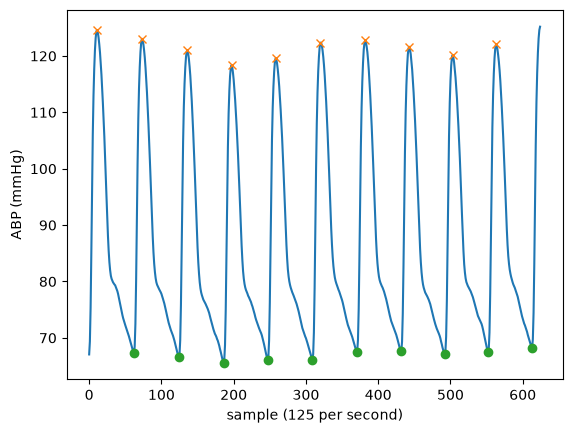

SBP: 121.84161810748634 DBP: 67.18506542667768


In [4]:
from scipy.signal import find_peaks   # to find the local tops/peaks of a signal
import matplotlib.pyplot as plt #for plotting

abp = abp_windows[0]   #ABP of the first window: 625 numbers = 5 seconds, in mmHg

# find_peaks returns 2 things: index of peaks, extra info we don't need (_)
# distance=40: peaks must be at least 40 samples (0.32 secs) apart, so the small second bump after
# each heartbeat (from the heart valve closing) isn't counted as its own beat, but fast heartbeats (up to ~187 bpm) still are
# prominence=10: a peak has to stick out at least 10 mmHg above its surroundings, so tiny noise wiggles
# between slow heartbeats aren't counted as peaks (real heartbeats stick out by tens of mmHg)
peaks, _ = find_peaks(abp, distance=40, prominence=10) # tops of the heartbeats -> systolic      
valleys, _ = find_peaks(-abp, distance=40, prominence=10)# flip the wave upside down so bottoms become tops -> diastolic

# how many beats were found: window 0 should have ~10 (it's ~120 bpm)
# saving this number for every window later will help with cleaning (the paper throws out windows with fewer than 2 peaks)
print("peaks found:", len(peaks), "valleys found:", len(valleys))

# plot the window and mark what find_peaks found, to check it by eye
plt.plot(abp) # the ABP wave                          
plt.plot(peaks, abp[peaks], "x") # x on every peak        
plt.plot(valleys, abp[valleys], "o") # o on every valley   
plt.xlabel("sample (125 per second)")
plt.ylabel("ABP (mmHg)")
plt.show()

# one label per window: the median/middle value, so one bad peak can't pull it off
print("SBP:", np.median(abp[peaks]), "DBP:", np.median(abp[valleys]))

Just like in the demo above, I'll do `find_peaks` on all 282,468 windows. For each window I save:
- **SBP, DBP**: median of the peaks / valleys (the labels)
- **n_peaks, n_valleys**: how many were found (for cleaning)
- **HR_peaks, HR_valleys**: heart rate in bpm from the median gap between peaks/valleys (the paper checks both)

If a window has no peaks, the label is `nan` (not a number) instead of a fake value --> cleaning throws those out.

In [6]:
# one list per thing I want to save: one value per window, same order as the rows of abp_windows
sbp_list, dbp_list = [], []
n_peaks_list, n_valleys_list = [], []
hr_peaks_list, hr_valleys_list = [], []

# looping over a 2D array gives one row = one 5-sec window at a time
for abp in abp_windows:
    
    peaks, _ = find_peaks(abp, distance=40, prominence=10)    # tops -> systolic
    valleys, _ = find_peaks(-abp, distance=40, prominence=10) # bottoms -> diastolic

    n_peaks_list.append(len(peaks))
    n_valleys_list.append(len(valleys))

    # no peaks --> nan instead of a label (np.median([]) gives nan too)
    sbp_list.append(np.median(abp[peaks]) if len(peaks) > 0 else np.nan)
    dbp_list.append(np.median(abp[valleys]) if len(valleys) > 0 else np.nan)

    # heart rate: np.diff gives the gaps between peaks (in samples); 125 samples = 1 sec, 60 secs = 1 min
    # --> bpm = 125 * 60 / median gap, needs at least 2 peaks to have a gap
    hr_peaks_list.append(125 * 60 / np.median(np.diff(peaks)) if len(peaks) >= 2 else np.nan)
    hr_valleys_list.append(125 * 60 / np.median(np.diff(valleys)) if len(valleys) >= 2 else np.nan)

# add everything to info as new columns: row i still = window i because I looped over the rows in order
info["SBP"] = sbp_list
info["DBP"] = dbp_list
info["n_peaks"] = n_peaks_list
info["n_valleys"] = n_valleys_list
info["HR_peaks"] = hr_peaks_list
info["HR_valleys"] = hr_valleys_list

print(info.loc[0]) # window 0: should match the demo cell (~10 peaks, ~120 bpm)
info.describe() # quick summary of every column (min, max, mean...)

part            1.000000
record          0.000000
window          0.000000
SBP           121.841618
DBP            67.185065
n_peaks        10.000000
n_valleys      10.000000
HR_peaks      122.950820
HR_valleys    122.950820
Name: 0, dtype: float64


,part,record,window,SBP,DBP,n_peaks,n_valleys,HR_peaks,HR_valleys
count,282468.000000,282468.000000,282468.000000,282358.000000,282370.000000,282468.000000,282468.000000,282239.000000,282240.000000
mean,1.535654,3029.255201,39.786404,130.255795,67.370711,7.337553,7.134390,90.022272,90.397647
std,0.498728,1786.324620,29.497993,22.653849,11.972834,1.625204,1.673049,19.786471,20.573832
min,1.000000,0.000000,0.000000,65.397619,50.000000,0.000000,0.000000,16.447368,13.812155
25%,1.000000,1447.000000,14.000000,113.181448,58.437029,6.000000,6.000000,75.376884,75.000000
50%,2.000000,3223.000000,34.000000,128.679793,64.620750,7.000000,7.000000,88.235294,88.235294
75%,2.000000,4567.000000,61.000000,146.871021,73.924429,8.000000,8.000000,100.671141,101.351351
max,2.000000,5999.000000,117.000000,199.635428,170.514768,16.000000,15.000000,187.500000,187.500000


### Part 4: Cleaning 

The Nature paper throws out windows where the ABP is broken/unrealistic. I use their rules and count how many windows each rule removes:
1. **ABP 30–220 mmHg**: checked on the raw window with `max`/`min` (before any peaks)
2. **Peak count**: 2–11 peaks and 3–12 valleys (fewer = broken signal, more = noise)
3. **Heart rate 35–140 bpm**: from both peaks and valleys
4. **Pulse pressure > 10**: SBP - DBP has to be more than 10 mmHg

I don't delete anything yet, I just mark each window in a `keep` column. The actual removing happens when I save,
so `info` and all 3 window matrices get filtered together and stay matched up.

Skipped for now: the paper's PPG-based rules (PPG heart rate, distortion, etc.).

In [7]:
# each rule = True for the windows I KEEP
# (keep-masks: anything that's nan counts as "not kept" automatically, because nan fails every comparison)
rules = {
    # axis=1 --> max/min across each row, so I get one number per window
    "ABP in 30-220 mmHg": (abp_windows.max(axis=1) <= 220) & (abp_windows.min(axis=1) >= 30),

    "2-11 peaks, 3-12 valleys": info["n_peaks"].between(2, 11) & info["n_valleys"].between(3, 12),

    "HR 35-140 bpm": info["HR_peaks"].between(35, 140) & info["HR_valleys"].between(35, 140),

    "pulse pressure > 10": (info["SBP"] - info["DBP"]) > 10,
}

keep = np.ones(len(info), dtype=bool)# start by keeping every window (one True per row in info)

for rule, apply_rule in rules.items(): # rule = the string, apply_it = its True/False for every window
    before = keep.sum() # how many windows are still kept (sum counts the Trues: True = 1, False = 0)
    keep = keep & apply_rule # & = "and": a window stays kept only if it was kept before AND passes this rule
    after = keep.sum()
    print(rule, "--> removed:", before - after, "left:", after)

info["keep"] = keep # save the final True/False for every window as a column in info
print("kept", keep.sum(), "of", len(info), "windows:", round(keep.sum() / len(info) * 100, 1), "%")

ABP in 30-220 mmHg --> removed: 0 left: 282468
2-11 peaks, 3-12 valleys --> removed: 5602 left: 276866
HR 35-140 bpm --> removed: 3368 left: 273498
pulse pressure > 10 --> removed: 1 left: 273497
kept 273497 of 282468 windows: 96.8 %


### Part 5: Missing values + saving

The cleaning rules only looked at the ABP, so a gap (`nan`) in the PPG (the model's input) or the ECG could still be in a kept window. I add one more rule: **no `nan` in any of the 3 signals.**

Then I save only the kept windows. Parts 1+2 = the **training** set, so the files start with `train_`.
The 3 matrices go in `.npy` files (NumPy files for numoy arrays) and `info` goes in a CSV.

In [8]:
# a nan = a gap in the recording (no measurement)
# np.isnan(...) gives True/False for every sample; .any(axis=1) asks "is there at least 1 nan in this row/window?"

for name, windows in {"PPG": ppg_windows, "ABP": abp_windows, "ECG": ecg_windows}.items():
    has_nan = np.isnan(windows).any(axis=1)# one True/False per window
    no_nan = has_nan == False # flipped: True = no gaps = keep it
    before = info["keep"].sum()
    info["keep"] = info["keep"] & no_nan # stays kept only if it was kept before AND has no gaps
    after = info["keep"].sum()
    print(name, "windows with nan:", has_nan.sum(), "--> removed:", before - after, "left:", after)

PPG windows with nan: 0 --> removed: 0 left: 273497
ABP windows with nan: 0 --> removed: 0 left: 273497
ECG windows with nan: 1 --> removed: 1 left: 273496


In [9]:
import os

# turn info["keep"] to plain NumPy True/False array, so it can pick rows out of the matrices
keep = info["keep"].to_numpy()

os.makedirs("data/processed", exist_ok=True)# make folder if it isn't there yet

#the SAME mask on all 3 matrices and on info, so row i still matches across all 4 files
np.save("data/processed/train_ppg.npy", ppg_windows[keep])
np.save("data/processed/train_abp.npy", abp_windows[keep])
np.save("data/processed/train_ecg.npy", ecg_windows[keep])

# info[keep] keeps the True rows; drop "keep" (it's all True now);
# reset_index renumbers the rows 0, 1, 2... so row i of the CSV = row i of each .npy file
train_info = info[keep].drop(columns="keep").reset_index(drop=True)
train_info.to_csv("data/processed/train_info.csv", index=False)

print("saved", len(train_info), "training windows")

saved 273496 training windows


### Part 6: EDA

I only look at the training windows (Parts 1+2, after cleaning), so nothing from the validation/test Parts influences my decisions. 3 questions to consider:
1. What SBP/DBP values will the model see? If a value is rare here, the model will probably be bad at it.
2. How far off is a "dumb" model that always guesses the average? Any real model has to beat that.
3. Do some recordings give way more windows than others? Long recordings could take over training.


In [10]:
# min/max/mean/quartiles of the labels and heart rate in the training windows
print(train_info[["SBP", "DBP", "HR_peaks"]].describe().round(1))

# "dumb" model: always guess the average. MAE (mean absolute error) = how many mmHg off, on average
# the paper's guess-the-average MAE: SBP 17.62, DBP 8.55 (on their test set, so this is only a rough comparison)
sbp_mae = np.mean(np.abs(train_info["SBP"] - train_info["SBP"].mean()))
dbp_mae = np.mean(np.abs(train_info["DBP"] - train_info["DBP"].mean()))
print("guess-the-average MAE --> SBP:", round(sbp_mae, 2), "DBP:", round(dbp_mae, 2))

            SBP       DBP  HR_peaks
count  273496.0  273496.0  273496.0
mean      130.1      67.1      88.5
std        22.5      11.6      16.7
min        66.8      50.0      35.5
25%       113.2      58.4      75.0
50%       128.5      64.5      87.7
75%       146.5      73.5     100.0
max       199.6     170.5     138.9
guess-the-average MAE --> SBP: 18.53 DBP: 9.08


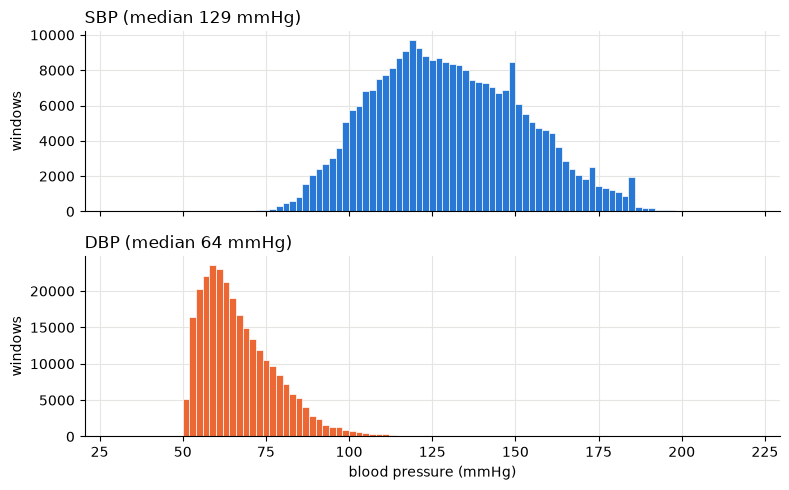

In [11]:
blue = "#2a78d6"
orange = "#eb6834"

# cleaner plots: no box on the top/right, light grid behind the bars
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e5e5e2", "axes.axisbelow": True})

bins = np.arange(30, 222, 2)   # bars 2 mmHg wide, from 30 to 220 (the cleaning range)

# 2 plots stacked, sharing the x axis so SBP and DBP are on the same mmHg scale
fig, (ax_sbp, ax_dbp) = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
ax_sbp.hist(train_info["SBP"], bins=bins, color=blue, edgecolor="white", linewidth=0.5)
ax_sbp.set_title(f"SBP (median {train_info['SBP'].median():.0f} mmHg)", loc="left")

ax_dbp.hist(train_info["DBP"], bins=bins, color=orange, edgecolor="white", linewidth=0.5)
ax_dbp.set_title(f"DBP (median {train_info['DBP'].median():.0f} mmHg)", loc="left")
ax_dbp.set_xlabel("blood pressure (mmHg)")

for ax in (ax_sbp, ax_dbp):
    ax.set_ylabel("windows")
plt.tight_layout()
plt.show()

recordings with at least 1 kept window: 5906 of 6000
count    5906.0
mean       46.3
std        39.6
min         1.0
25%         8.0
50%        35.0
75%        83.0
max       118.0
Name: count, dtype: float64


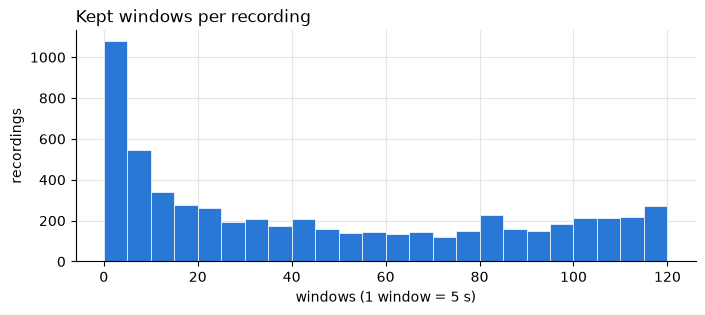

In [13]:
# value_counts counts how often each record number appears = how many kept windows each recording gives
windows_per_record = train_info["record"].value_counts()
print("recordings with at least 1 kept window:", len(windows_per_record), "of 6000")
print(windows_per_record.describe().round(1))

plt.figure(figsize=(8, 3))
plt.hist(windows_per_record, bins=range(0, windows_per_record.max() + 5, 5), color=blue, edgecolor="white", linewidth=0.5)   # bars 5 windows wide
plt.title("Kept windows per recording", loc="left")
plt.xlabel("windows (1 window = 5 s)")
plt.ylabel("recordings")
plt.show()